<a href="https://colab.research.google.com/github/AlejandroVasquez3/DDDS-My-Projects/blob/main/Project-5/Project_5_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title

### Resources
- [3c - wiki](https://colab.research.google.com/drive/13JnaW8-TNqZ2VhADf7c6MvqJ5mQ1107j#scrollTo=xDuCEa4Z-mwb)
- [2b - Wiki API](https://colab.research.google.com/drive/1VUxB2T_mgAGcrfrHhAbWe-KUdy1fCvoq)

## Problem Definition


State the business problem. Translate the business problem into a Data Science problem by stating what kind of problem it is ( supervised vs unsupervised ) and whether it is a classification, regression, or clustering problem.

### Import Needed Libraries

In [2]:
%%capture
!python -m textblob.download_corpora


In [3]:
!pip install -U textblob wikipedia-api
!python -m textblob.download_corpora

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia-api: filename=Wikipedia_API-0.8.1-py3-none-any.whl size=15383 sha256=003c4969f81eb3e2f086b1d63bcc8579bd641cc39368604c676732ce5269c921
  Stored in directory: /root/.cache/pip/wheels/0b/0f/39/e8214ec038ccd5aeb8c82b957289f2f3ab2251febeae5c2860
Successfully built wikipedia-api
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Package conll2000 is already up-to-d

In [4]:
%%capture output
#install Wikipedia API
!pip3 install wikipedia-api


In [227]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.neighbors import NearestNeighbors

pd.options.display.max_columns = 100
import wikipediaapi
import re
import random
import nltk
# nltk.download('omw-1.4')
nltk.download('punkt_tab')
# nltk.download('averaged_perceptron_tagger_eng')
from textblob import TextBlob

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Data Collection/Sources


In [6]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv"

In [7]:
text_data = pd.read_csv(url)
text_data.head()

,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...


In [8]:
text_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42786 entries, 0 to 42785
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   URI     42786 non-null  object
 1   name    42786 non-null  object
 2   text    42786 non-null  object
dtypes: object(3)
memory usage: 1002.9+ KB


In [9]:
text_data["name"].value_counts()

,count
name,
author),2
Kate Fodor,1
Kreg Battles,1
Robert Earnshaw,1
Clay Christiansen (organist),1
...,...
Chet Walker,1
Andreas Vanpoucke,1
Jill Robinson,1


## Data Cleaning


#### Clean Text and Name columns


In [10]:
text_data["text_clean"] = text_data["text"].apply(
    lambda x: re.sub(r"(\\n|'s|'|\"|\\(|\\)|-)+", " ", x.lower())
)

In [11]:
text_data["name_clean_with_extra"] = text_data["name"].apply(
    lambda x: re.sub(r"(\\n|'s|'|\"|\\(|\\)|-)+", " ", x.lower())
)

In [12]:
text_data["name_clean_final"] = text_data["name_clean_with_extra"].apply(
    lambda x: re.sub(r"(?:%A4|%A1|%B6|%C3)+", "", x)
)

In [13]:
text_data.head(10)

,URI,name,text,text_clean,name_clean_with_extra,name_clean_final
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...,digby morrell born 10 october 1979 is a former...,digby morrell,digby morrell
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...,alfred j lewy aka sandy lewy graduated from un...,alfred j. lewy,alfred j. lewy
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...,harpdog brown is a singer and harmonica player...,harpdog brown,harpdog brown
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...,franz rottensteiner born in waidmannsfeld lowe...,franz rottensteiner,franz rottensteiner
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...,henry krvits born 30 december 1974 in tallinn ...,g enka,g enka
5,<http://dbpedia.org/resource/Sam_Henderson>,Sam Henderson,sam henderson born october 18 1969 is an ameri...,sam henderson born october 18 1969 is an ameri...,sam henderson,sam henderson
6,<http://dbpedia.org/resource/Aaron_LaCrate>,Aaron LaCrate,aaron lacrate is an american music producer re...,aaron lacrate is an american music producer re...,aaron lacrate,aaron lacrate
7,<http://dbpedia.org/resource/Trevor_Ferguson>,Trevor Ferguson,trevor ferguson aka john farrow born 11 novemb...,trevor ferguson aka john farrow born 11 novemb...,trevor ferguson,trevor ferguson
8,<http://dbpedia.org/resource/Grant_Nelson>,Grant Nelson,grant nelson born 27 april 1971 in london also...,grant nelson born 27 april 1971 in london also...,grant nelson,grant nelson
9,<http://dbpedia.org/resource/Cathy_Caruth>,Cathy Caruth,cathy caruth born 1955 is frank h t rhodes pro...,cathy caruth born 1955 is frank h t rhodes pro...,cathy caruth,cathy caruth


#### Lemmatization

In [14]:

lemmatized_texts = []
for index, text in text_data['text_clean'].items(): # .items() gives both index and value

    bl = TextBlob(text)

    lemmas = [word.lemmatize() for word in bl.words] # Apply lemmatization
    lemmatized_text = " ".join(lemmas) # Join the lemmas back into a single string
    lemmatized_texts.append(lemmatized_text)


In [15]:

text_data['text_lemmatized'] = lemmatized_texts

In [16]:
text_data.to_csv('nlp_processed_data.csv', index=False)

## Part 1

In [279]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(text_data['text_lemmatized'])
print("TF-IDF Vectorization complete.")

TF-IDF Vectorization complete.


### K Nearest Neighbors


In [280]:
nn_model = NearestNeighbors(n_neighbors=11, metric='cosine') # or 'euclidean'
nn_model.fit(tfidf_matrix)

NearestNeighbors(metric='cosine', n_neighbors=11)

In [321]:
# np.random.seed(40)
np.random.seed(333)
target_person = text_data.sample(n=1)
target_person

,URI,name,text,text_clean,name_clean_with_extra,name_clean_final,text_lemmatized
39545,<http://dbpedia.org/resource/Stuart_L._Deutsch>,Stuart L. Deutsch,stuart l deutsch was dean and professor of law...,stuart l deutsch was dean and professor of law...,stuart l. deutsch,stuart l. deutsch,stuart l deutsch wa dean and professor of law ...


In [322]:
target_person_lemmatized_text = target_person['text_lemmatized'].iloc[0]

In [323]:
target_person_tfidf_vector = tfidf_vectorizer.transform([target_person_lemmatized_text])


In [324]:
distances, indices = nn_model.kneighbors(target_person_tfidf_vector)

In [325]:
# The first index will  be the target person itself (distance 0)
print("\nNearest Neighbors (indices in original DataFrame):")
print(f"{indices[0].tolist()}\n\n")

# Retrieve the information for the nearest neighbors
nearest_neighbors_info = text_data.iloc[indices[0]]

print("="*70)
print(f"TARGET PERSON:\n{target_person[['name']]}")
print("="*70)
print("\n\nInformation for Nearest Neighbors:")
print(nearest_neighbors_info[['name']])
print(nearest_neighbors_info[['text']])


Nearest Neighbors (indices in original DataFrame):
[39545, 15131, 37193, 38301, 28699, 36287, 42547, 19305, 8266, 56, 13843]


TARGET PERSON:
                    name
39545  Stuart L. Deutsch


Information for Nearest Neighbors:
                                  name
39545                Stuart L. Deutsch
15131          Bernard Bell (attorney)
37193          Barry Sullivan (lawyer)
38301                     Joan Mahoney
28699                       Jody Kraus
36287                 David G. Epstein
42547               Paul Schiff Berman
19305                  Patricia Salkin
8266                       Steven Wilf
56             Susan Westerberg Prager
13843  Richard Lazarus (law professor)
                                                    text
39545  stuart l deutsch was dean and professor of law...
15131  bernard bell is the associate dean for academi...
37193  barry sullivan is a chicago lawyer and as of j...
38301  joan mahoney born 1943 is a legal scholar and ...
28699  jody s kra

In [326]:
part1_rank = pd.DataFrame()
# part1_rank["rank_csv"] = range(len(nearest_neighbors_info["name"]))
part1_rank["name"] = nearest_neighbors_info["name"]
part1_rank["text"] = nearest_neighbors_info["text"]

rank_list = list(range(11))
part1_rank["rank"] = rank_list[:len(part1_rank)]
part1_rank

,name,text,rank
39545,Stuart L. Deutsch,stuart l deutsch was dean and professor of law...,0
15131,Bernard Bell (attorney),bernard bell is the associate dean for academi...,1
37193,Barry Sullivan (lawyer),barry sullivan is a chicago lawyer and as of j...,2
38301,Joan Mahoney,joan mahoney born 1943 is a legal scholar and ...,3
28699,Jody Kraus,jody s kraus is a noted expert on contracts an...,4
36287,David G. Epstein,david gustav epstein is the george e allen pro...,5
42547,Paul Schiff Berman,paul schiff berman is an american lawyer and t...,6
19305,Patricia Salkin,patricia e salkin is the dean of touro college...,7
8266,Steven Wilf,steven r wilf is a professor of law at the uni...,8
56,Susan Westerberg Prager,susan westerberg prager 1942 is an american le...,9


### Sentiment **Overview**

In [327]:
target_str = str(target_person['name'].iloc[0])

In [328]:
target_pol = TextBlob(target_person['text'].iloc[0]).sentiment.polarity
target_sub = TextBlob(target_person['text'].iloc[0]).sentiment.subjectivity
print(f"The given text on {target_str} has a polarity of {target_pol:.3f}\n")

print(f"The given text on {target_str} has a polarity of {target_sub:.3f}\n")

The given text on Stuart L. Deutsch has a polarity of 0.165

The given text on Stuart L. Deutsch has a polarity of 0.318



## Part 2

## Wiki API


#### Printing out Wiki Text

In [329]:
topic = target_str
wikip = wikipediaapi.Wikipedia('foobar')
page_ex = wikip.page(topic)
wiki_text = page_ex.text
print(f"This wiki is about: {target_str}\n")
wiki_text


This wiki is about: Stuart L. Deutsch



"Stuart L. Deutsch was Dean and Professor of Law at Rutgers School of Law–Newark from 1999 to 2009. Upon stepping down as dean, he was awarded the title of University Professor in recognition of his service as dean.\nFormerly a professor of law, co-director of the Program in Environmental and Energy Law, and founding director of the Institute for Science, Law, and Technology at the Chicago-Kent College of Law at the Illinois Institute of Technology, he also served as interim dean in 1996–97, and as associate dean for academic affairs and associate dean for interdisciplinary programs. Deutsch's expertise at that time, prior to his becoming a university administrator, was in the fields of environmental law and land use. He authored Deutsch's Illinois Environmental Laws Annotated, and for 18 years was coeditor of Land Use and Environment Law Review. He also practiced law in New York City, even though he never received his law license from the State of New York.  Deutsch earned his J.D. fr

#### Wiki Text Clean

In [330]:
wiki_text_clean = (
  wiki_text
  .lower()
  .replace("\n"," ")
  .replace("\'s",'')
  .replace('\'','')
  .replace("(", "")
  .replace(")", "")
  .replace('"', "")
)
wiki_text_clean


'stuart l. deutsch was dean and professor of law at rutgers school of law–newark from 1999 to 2009. upon stepping down as dean, he was awarded the title of university professor in recognition of his service as dean. formerly a professor of law, co-director of the program in environmental and energy law, and founding director of the institute for science, law, and technology at the chicago-kent college of law at the illinois institute of technology, he also served as interim dean in 1996–97, and as associate dean for academic affairs and associate dean for interdisciplinary programs. deutsch expertise at that time, prior to his becoming a university administrator, was in the fields of environmental law and land use. he authored deutsch illinois environmental laws annotated, and for 18 years was coeditor of land use and environment law review. he also practiced law in new york city, even though he never received his law license from the state of new york.  deutsch earned his j.d. from ya

In [331]:
wiki_blob = TextBlob(wiki_text_clean)
wiki_blob

TextBlob("stuart l. deutsch was dean and professor of law at rutgers school of law–newark from 1999 to 2009. upon stepping down as dean, he was awarded the title of university professor in recognition of his service as dean. formerly a professor of law, co-director of the program in environmental and energy law, and founding director of the institute for science, law, and technology at the chicago-kent college of law at the illinois institute of technology, he also served as interim dean in 1996–97, and as associate dean for academic affairs and associate dean for interdisciplinary programs. deutsch expertise at that time, prior to his becoming a university administrator, was in the fields of environmental law and land use. he authored deutsch illinois environmental laws annotated, and for 18 years was coeditor of land use and environment law review. he also practiced law in new york city, even though he never received his law license from the state of new york.  deutsch earned his j.d

#### Wiki Sentiment

In [332]:
wiki_pol = wiki_blob.sentiment.polarity
wiki_sub = wiki_blob.sentiment.subjectivity
print(f"The Wiki on {target_str} has a polarity of {wiki_pol:.3f}\n")
print(f"The Wiki on {target_str} has a subjectivity of {wiki_sub:.3f}\n")

The Wiki on Stuart L. Deutsch has a polarity of 0.172

The Wiki on Stuart L. Deutsch has a subjectivity of 0.332



#### Wiki 10 Nearest neighbors - Wiki pages

In [333]:
wiki_names = nearest_neighbors_info["name"].to_list()
wiki_names

['Stuart L. Deutsch',
 'Bernard Bell (attorney)',
 'Barry Sullivan (lawyer)',
 'Joan Mahoney',
 'Jody Kraus',
 'David G. Epstein',
 'Paul Schiff Berman',
 'Patricia Salkin',
 'Steven Wilf',
 'Susan Westerberg Prager',
 'Richard Lazarus (law professor)']

In [334]:
full_wiki_texts_raw = {}
full_wiki_texts_lemmatized = {} # To store cleaned and lemmatized versions

print("Starting to fetch Wikipedia texts for the following names:")
for name in wiki_names:
    print(f"  - {name}")

    page_py = wikip.page(name) # Get the Wikipedia page object for the current name
    raw_text = page_py.text # Get the raw text of the Wikipedia page
    full_wiki_texts_raw[name] = raw_text

    # Clean text and apply Lemmatization
    cleaned_text = re.sub(r"(?:\\n|'s|'|\"|\\(|\\)|-)+", " ", raw_text.lower())
    blob = TextBlob(cleaned_text)
    lemmas = [word.lemmatize() for word in blob.words]
    lemmatized_text = " ".join(lemmas)
    full_wiki_texts_lemmatized[name] = lemmatized_text

print("\nFinished fetching Wikipedia texts.")

Starting to fetch Wikipedia texts for the following names:
  - Stuart L. Deutsch
  - Bernard Bell (attorney)
  - Barry Sullivan (lawyer)
  - Joan Mahoney
  - Jody Kraus
  - David G. Epstein
  - Paul Schiff Berman
  - Patricia Salkin
  - Steven Wilf
  - Susan Westerberg Prager
  - Richard Lazarus (law professor)

Finished fetching Wikipedia texts.


In [335]:
wiki_texts_df = pd.DataFrame.from_dict(full_wiki_texts_lemmatized, orient='index', columns=['text'])

In [336]:
wiki_texts_df

,text
Stuart L. Deutsch,stuart l deutsch wa dean and professor of law ...
Bernard Bell (attorney),bernard bell is the associate dean for academi...
Barry Sullivan (lawyer),barry sullivan is a chicago lawyer professor o...
Joan Mahoney,joan mahoney born 1943 is a legal scholar and ...
Jody Kraus,jody s ponsa kraus is a patricia d and r paul ...
David G. Epstein,david gustav epstein is the george e allen pro...
Paul Schiff Berman,paul schiff berman born february 12 1966 is an...
Patricia Salkin,patricia e salkin is an american jurist she is...
Steven Wilf,steven r wilf is a professor of law at the uni...
Susan Westerberg Prager,susan westerberg prager born december 14 1942 ...


### Wiki 10 Nearest neighbors - Ranking based on wiki pages

In [337]:
wiki_tfidf_vectorizer = TfidfVectorizer(stop_words='english')
wiki_tfidf_matrix = wiki_tfidf_vectorizer.fit_transform(wiki_texts_df['text'])
print("TF-IDF Vectorization complete.")

TF-IDF Vectorization complete.


In [338]:
target_full_wiki_tfidf_vector = wiki_tfidf_matrix[0]

In [339]:
nn_model_wiki = NearestNeighbors(n_neighbors=11, metric='cosine') # or 'euclidean'
nn_model_wiki.fit(wiki_tfidf_matrix)

NearestNeighbors(metric='cosine', n_neighbors=11)

In [340]:
distances_wiki, indices_wiki = nn_model_wiki.kneighbors(target_full_wiki_tfidf_vector)

In [341]:
target_person_wiki_text = wiki_texts_df.loc[target_str]['text']
target_person_wiki_text

'stuart l deutsch wa dean and professor of law at rutgers school of law–newark from 1999 to 2009 upon stepping down a dean he wa awarded the title of university professor in recognition of his service a dean formerly a professor of law co director of the program in environmental and energy law and founding director of the institute for science law and technology at the chicago kent college of law at the illinois institute of technology he also served a interim dean in 1996–97 and a associate dean for academic affair and associate dean for interdisciplinary program deutsch expertise at that time prior to his becoming a university administrator wa in the field of environmental law and land use he authored deutsch illinois environmental law annotated and for 18 year wa coeditor of land use and environment law review he also practiced law in new york city even though he never received his law license from the state of new york deutsch earned his j.d from yale law school in 1969 and his ll.

In [342]:
target_person_tfidf_vector = tfidf_vectorizer.transform([target_person_wiki_text])
# target_person_tfidf_vector = wiki_tfidf_vectorizer.transform([target_person_wiki_text])

In [343]:
distances_wiki

array([[3.33066907e-16, 6.69948647e-01, 6.70816780e-01, 6.92164299e-01,
        7.32507455e-01, 7.41702055e-01, 7.58653875e-01, 7.72079382e-01,
        7.75096026e-01, 7.90578853e-01, 8.30962066e-01]])

In [344]:
indices_wiki

array([[ 0,  1,  2,  7, 10,  3,  8,  4,  6,  5,  9]])

In [345]:
indices_wiki[0].tolist()

[0, 1, 2, 7, 10, 3, 8, 4, 6, 5, 9]

In [346]:
wiki_texts_df.iloc[indices_wiki[0].tolist()]


,text
Stuart L. Deutsch,stuart l deutsch wa dean and professor of law ...
Bernard Bell (attorney),bernard bell is the associate dean for academi...
Barry Sullivan (lawyer),barry sullivan is a chicago lawyer professor o...
Patricia Salkin,patricia e salkin is an american jurist she is...
Richard Lazarus (law professor),richard j lazarus is an american legal scholar...
Joan Mahoney,joan mahoney born 1943 is a legal scholar and ...
Steven Wilf,steven r wilf is a professor of law at the uni...
Jody Kraus,jody s ponsa kraus is a patricia d and r paul ...
Paul Schiff Berman,paul schiff berman born february 12 1966 is an...
David G. Epstein,david gustav epstein is the george e allen pro...


In [347]:
wiki_texts_df["rank"] = rank_list[:len(wiki_texts_df)]
wiki_texts_df = wiki_texts_df.reset_index().rename(columns={'index': 'name'})
wiki_texts_df

,name,text,rank
0,Stuart L. Deutsch,stuart l deutsch wa dean and professor of law ...,0
1,Bernard Bell (attorney),bernard bell is the associate dean for academi...,1
2,Barry Sullivan (lawyer),barry sullivan is a chicago lawyer professor o...,2
3,Joan Mahoney,joan mahoney born 1943 is a legal scholar and ...,3
4,Jody Kraus,jody s ponsa kraus is a patricia d and r paul ...,4
5,David G. Epstein,david gustav epstein is the george e allen pro...,5
6,Paul Schiff Berman,paul schiff berman born february 12 1966 is an...,6
7,Patricia Salkin,patricia e salkin is an american jurist she is...,7
8,Steven Wilf,steven r wilf is a professor of law at the uni...,8
9,Susan Westerberg Prager,susan westerberg prager born december 14 1942 ...,9


### Plot nearest ranking

In [348]:
wiki_texts_df

,name,text,rank
0,Stuart L. Deutsch,stuart l deutsch wa dean and professor of law ...,0
1,Bernard Bell (attorney),bernard bell is the associate dean for academi...,1
2,Barry Sullivan (lawyer),barry sullivan is a chicago lawyer professor o...,2
3,Joan Mahoney,joan mahoney born 1943 is a legal scholar and ...,3
4,Jody Kraus,jody s ponsa kraus is a patricia d and r paul ...,4
5,David G. Epstein,david gustav epstein is the george e allen pro...,5
6,Paul Schiff Berman,paul schiff berman born february 12 1966 is an...,6
7,Patricia Salkin,patricia e salkin is an american jurist she is...,7
8,Steven Wilf,steven r wilf is a professor of law at the uni...,8
9,Susan Westerberg Prager,susan westerberg prager born december 14 1942 ...,9


In [349]:
part1_rank

,name,text,rank
39545,Stuart L. Deutsch,stuart l deutsch was dean and professor of law...,0
15131,Bernard Bell (attorney),bernard bell is the associate dean for academi...,1
37193,Barry Sullivan (lawyer),barry sullivan is a chicago lawyer and as of j...,2
38301,Joan Mahoney,joan mahoney born 1943 is a legal scholar and ...,3
28699,Jody Kraus,jody s kraus is a noted expert on contracts an...,4
36287,David G. Epstein,david gustav epstein is the george e allen pro...,5
42547,Paul Schiff Berman,paul schiff berman is an american lawyer and t...,6
19305,Patricia Salkin,patricia e salkin is the dean of touro college...,7
8266,Steven Wilf,steven r wilf is a professor of law at the uni...,8
56,Susan Westerberg Prager,susan westerberg prager 1942 is an american le...,9


In [350]:
comparison_df = pd.merge(part1_rank[["name","rank"]], wiki_texts_df[["name", "rank"]], on= "name", how="inner")
comparison_df = comparison_df.rename(columns={'rank_x': 'part1_rank',"rank_y": "wiki_rank"}) # FIX: Assign back
comparison_df["rank_difference"] = abs(comparison_df["part1_rank"] - comparison_df["wiki_rank"])
comparison_df

,name,part1_rank,wiki_rank,rank_difference
0,Stuart L. Deutsch,0,0,0
1,Bernard Bell (attorney),1,1,0
2,Barry Sullivan (lawyer),2,2,0
3,Joan Mahoney,3,3,0
4,Jody Kraus,4,4,0
5,David G. Epstein,5,5,0
6,Paul Schiff Berman,6,6,0
7,Patricia Salkin,7,7,0
8,Steven Wilf,8,8,0
9,Susan Westerberg Prager,9,9,0


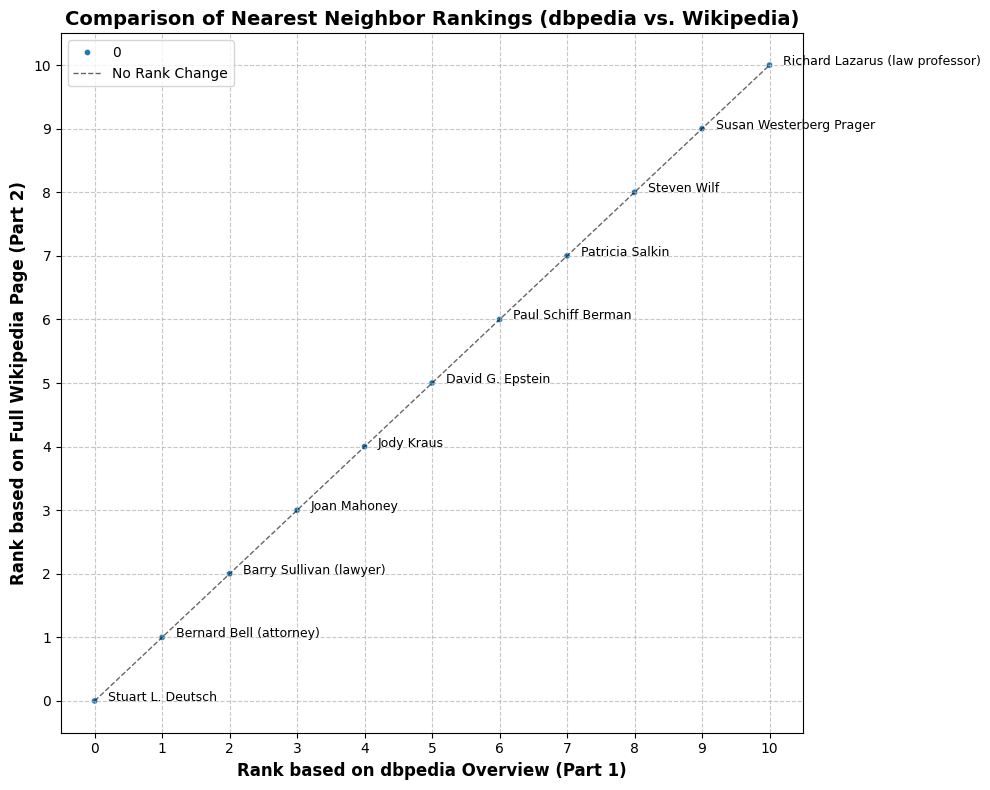

In [366]:
# Scatter plot for direct comparison
plt.figure(figsize=(10, 8))
sns.scatterplot(data=comparison_df, x='part1_rank', y='wiki_rank', hue='rank_difference', size='rank_difference', sizes=(20, 400), legend='full')
plt.plot([0, 10], [0, 10], 'k--', lw=1, alpha=0.6, label='No Rank Change') # Diagonal line for no change
# Add labels for each point (person's name)
for i, row in comparison_df.iterrows():
    plt.text(row['part1_rank'] + 0.2, row['wiki_rank'], row['name'], fontsize=9)

plt.title('Comparison of Nearest Neighbor Rankings (dbpedia vs. Wikipedia)', weight= "bold", fontsize = 14)
plt.xlabel('Rank based on dbpedia Overview (Part 1)', weight= "bold", fontsize = 12)
plt.ylabel('Rank based on Full Wikipedia Page (Part 2)', weight= "bold", fontsize = 12)
plt.xticks(range(11))
plt.yticks(range(11))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("comp_nn_dbpedia_wiki.png", dpi=300)
plt.show()


## Part 3 - Interactive

In [368]:
chosen_name = input("Whats the name?: \n")

Whats the name?: 
Jody Kraus


In [369]:
chosen_name

'Jody Kraus'

In [370]:
target_person = text_data[text_data["name"] == chosen_name]
target_person

,URI,name,text,text_clean,name_clean_with_extra,name_clean_final,text_lemmatized
28699,<http://dbpedia.org/resource/Jody_Kraus>,Jody Kraus,jody s kraus is a noted expert on contracts an...,jody s kraus is a noted expert on contracts an...,jody kraus,jody kraus,jody s kraus is a noted expert on contract and...


In [371]:
target_person_lemmatized_text = target_person['text_lemmatized'].iloc[0]

In [372]:
target_person_tfidf_vector = tfidf_vectorizer.transform([target_person_lemmatized_text])


In [373]:
distances, indices = nn_model.kneighbors(target_person_tfidf_vector)

In [379]:
# The first index will  be the target person itself (distance 0)
print("\nNearest Neighbors (indices in original DataFrame):")
print(f"{indices[0]}\n\n")

# Retrieve the information for the nearest neighbors
nearest_neighbors_info = text_data.iloc[indices[0]]

print("="*70)
print(f"TARGET PERSON:\n{target_person[['name']]}")
print("="*70)
print("\n\nInformation for Nearest Neighbors:")
print(nearest_neighbors_info[['name']])
print(nearest_neighbors_info[['text']])


Nearest Neighbors (indices in original DataFrame):
[28699 36287 15131 13470 42547 27500 40320 38301  9267 13843 28698]


TARGET PERSON:
             name
28699  Jody Kraus


Information for Nearest Neighbors:
                                  name
28699                       Jody Kraus
36287                 David G. Epstein
15131          Bernard Bell (attorney)
13470                      Cole Durham
42547               Paul Schiff Berman
27500                  Robert E. Scott
40320  Chris Guthrie (law school dean)
38301                     Joan Mahoney
9267               Vikramaditya Khanna
13843  Richard Lazarus (law professor)
28698                       Ugo Mattei
                                                    text
28699  jody s kraus is a noted expert on contracts an...
36287  david gustav epstein is the george e allen pro...
15131  bernard bell is the associate dean for academi...
13470  w cole durham jr born february 26 1948 is an a...
42547  paul schiff berman is an ameri